In [1]:
using DelimitedFiles

In [3]:
open("mostunstable.dat", "w") do io
    for R = 50 : 5 : 500
        data = readdlm("R=$R.dat",skipstart=3)
        for i = 2 : size(data,1)
            if data[i,5]> data[i-1,5] && data[i,5] > data[i+1,5] && data[i,5] > 0
                mostunstable = data[i,:]
                writedlm(io, [mostunstable])
            end
        end
    end
end

In [3]:
open("Stability_Zarf_Ts=-0.2_statecorr.dat", "w") do io
    for R = 50 : 5 : 500
        data = readdlm("R=$R.dat",skipstart=3)
        data[:,4] .+= data[:,3]
        writedlm(io, data)
    end
end

In [ ]:
TITLE = "Stability Analysis"
VARIABLES = "R", "alpha", "beta", "omega_r", "omega_i"
ZONE T="R=450", I=121, J=71, K=91,F=POINT

In [2]:
using DelimitedFiles

In [4]:
# 提取中性曲线: omega_i = 0 处的 (R, beta, Omega)
# 数据结构: I=121 (alpha), J=71 (beta), 外层 alpha, 内层 beta

function extract_neutral_curve(R_values, target_Omega, tol_Omega)
    rows = Vector{Float64}[]   # 收集每一行 [R, beta, Omega, alpha]
    
    for R in R_values
        filepath = "R=$R.dat"
        if !isfile(filepath)
            continue
        end
        data = readdlm(filepath, skipstart=3)
        
        # 提取唯一 alpha/beta
        alpha_vec = unique(data[:,2])
        beta_vec  = unique(data[:,3])
        n_alpha = length(alpha_vec)
        n_beta  = length(beta_vec)
        
        # reshape 为 (n_alpha × n_beta) 矩阵
        omega_r_mat = reshape(data[:,4], n_beta, n_alpha)'  # (n_alpha, n_beta)
        omega_i_mat = reshape(data[:,5], n_beta, n_alpha)'
        
        # 对每个 alpha，沿 beta 方向找 omega_i 过零点
        for i_alpha in 1:n_alpha
            for i_beta in 1:n_beta-1
                wi1 = omega_i_mat[i_alpha, i_beta]
                wi2 = omega_i_mat[i_alpha, i_beta+1]
                
                # 检测过零（异号）
                if wi1 * wi2 < 0
                    b1, b2 = beta_vec[i_beta], beta_vec[i_beta+1]
                    wr1, wr2 = omega_r_mat[i_alpha, i_beta], omega_r_mat[i_alpha, i_beta+1]
                    
                    # 线性插值
                    t = abs(wi1) / (abs(wi1) + abs(wi2))
                    beta_neutral = b1 + t * (b2 - b1)
                    wr_neutral   = wr1 + t * (wr2 - wr1)
                    Omega = R * wr_neutral
                    
                    # 检查是否接近目标 Omega
                    if abs(Omega - target_Omega) < tol_Omega
                        push!(rows, [R, beta_neutral, Omega, alpha_vec[i_alpha]])
                    end
                end
            end
        end
    end
    
    if isempty(rows)
        return zeros(0, 4)
    end
    return reduce(vcat, rows')  # 堆叠为矩阵
end

# 参数设置
R_values = 50:5:500
target_Omega = 8.0    # 指定的 Omega = R * omega_r
tol_Omega = 0.5       # Omega 容差

result = extract_neutral_curve(R_values, target_Omega, tol_Omega)

# 按 R 排序并保存
if size(result,1) > 0
    result_sorted = result[sortperm(result[:,1]), :]
    writedlm("neutral_Omega=$(target_Omega).dat", result_sorted)
    @show size(result)
else
    println("No neutral points found for Omega = $target_Omega")
end

size(result) = (122, 4)


(122, 4)

Omega = -4.0: 21 points found
Omega = 0.0: 35 points found
Omega = 4.0: 146 points found
Omega = 8.0: 63 points found


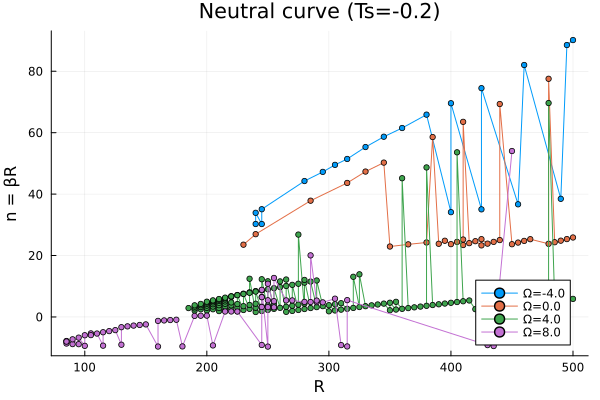

In [11]:
# 批量提取多个 Omega 的中性曲线
using Plots

R_values = 50:5:500
Omega_list = [-4.0,0.0,4.0,8.0]  # 指定 Omega 值
tol = 0.25

all_results = []
for (i, Omega_target) in enumerate(Omega_list)
    result = extract_neutral_curve(R_values, Omega_target, tol)
    if size(result, 1) > 0
        push!(all_results, (Omega_target, result))
        println("Omega = $Omega_target: $(size(result,1)) points found")
    end
end

# 绘图：横轴 R，纵轴 n = β * R
p = plot(xlabel="R", ylabel="n = βR", title="Neutral curve (Ts=-0.2)", legend=:bottomright)
for (Omega_target, result) in all_results
    n = result[:,2] .* result[:,1]  # n = beta * R
    plot!(p, result[:,1], n, marker=:circle, ms=3, label="Ω=$Omega_target")
end
display(p)

# 保存（增加 n = β * R 列）
for (Omega_target, result) in all_results
    n = result[:,2] .* result[:,1]  # n = beta * R
    output = [result n]             # [R, beta, Omega, alpha, n]
    writedlm("neutral_Omega=$(Omega_target).dat", output)
end